# Imports

In [ ]:
import pandas_gbq
import pandas as pd
import numpy as np

# Query function

In [ ]:
def read_query(query,
               project_id = 'physionet-data-468110',
               dataset = None,
               subject_id = None):
  # Should automatically direct to auth page
  # query: standard SQL syntax
  # Return: pandas.Dataframe
  return pandas_gbq.read_gbq(query, project_id=project_id)

# Keith's Query for MI

Again, note that we set `seq_num <= 10` to be more liberal and let the troponin do the in-depth filtering

## Query string

In [ ]:
query = f"""
# previous config
# k=10, gap=6, troponin_min_url=0.4, pre_hours=12, post_hours=24


# seq_num = 1 indicates primary diagnoses.
#  Idea: include hosp admissions where the top-k diagnosis match the CHD-related ICD codes? seq_num <= k
DECLARE k INT64 DEFAULT 10;
DECLARE gap FLOAT64 DEFAULT 24;
DECLARE troponin_min_url FLOAT64 DEFAULT 0.4;   -- preferrably assay URL
DECLARE pre_hours  INT64 DEFAULT 12;             -- look-back window
DECLARE post_hours INT64 DEFAULT 24;             -- look-forward window

#########################################
# PART I: OBTAIN RELEVANT ICU STAYS AND LABEL THEM
#########################################
# 1.1 hard code ICD codes from phekb .xlsx
WITH raw_phekb_codes AS (
  SELECT code FROM UNNEST([
    '410.00','410.01','410.02','410.10','410.11','410.12','410.20','410.21','410.22',
    '410.30','410.31','410.32','410.40','410.41','410.42','410.50','410.51','410.52',
    '410.60','410.61','410.62','410.70','410.71','410.72','410.80','410.81','410.82',
    '410.90','410.91','410.92','412','429.71','429.79',
    'I21.01','I21.02','I21.09','I21.11','I21.19','I21.21','I21.29','I21.3','I21.4',
    'I22.0','I22.1','I22.2','I22.8','I22.9',
    'I23.0','I23.1','I23.2','I23.3','I23.4','I23.5','I23.6','I23.7','I23.8',
    'I24.1','I25.2'
  ]) AS code
),
phekb_chd_codes AS (
  SELECT
    REPLACE(UPPER(code), '.', '') AS icd_code,                              -- e.g., '410.01' -> '41001', 'I21.4' -> 'I214'
    CASE WHEN REGEXP_CONTAINS(UPPER(code), r'^[A-Z]') THEN 10 ELSE 9 END AS icd_version
  FROM raw_phekb_codes
),
# 1.2 identify CHD hospital admissions based on ICD codes (at least, their prefixes) in 1.1
chd_admissions_raw AS (
  # SELECT DISTINCT t1.subject_id, t1.hadm_id
  # SELECT *
  SELECT t1.subject_id, t1.hadm_id, t2.icd_code, t2.icd_version, t2.long_title
  FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` AS t1
  JOIN `physionet-data.mimiciv_3_1_hosp.d_icd_diagnoses` AS t2
    ON t1.icd_code = t2.icd_code
   AND t1.icd_version = t2.icd_version
  JOIN phekb_chd_codes p
    ON p.icd_version = t1.icd_version
   AND t1.icd_code = p.icd_code   # ICD codes exact match
  WHERE t1.seq_num <= k
),

# 1.2.1 Minimal set of columns (for joining to ICU stays)
chd_admissions AS (
  SELECT DISTINCT subject_id, hadm_id
  FROM chd_admissions_raw
),


# 2. ICU stays for those admissions
chd_icustays AS (
  SELECT i.subject_id, i.hadm_id, i.stay_id, i.intime, i.outtime
  FROM `physionet-data.mimiciv_3_1_icu.icustays` i
  JOIN chd_admissions c
    ON i.subject_id = c.subject_id
   AND i.hadm_id    = c.hadm_id
),

# 3. label the data based on ICU readmission (y=0 or 1)
# 3.1 LEAD(intime): for each ICU stay (which has an `intime`), we look ahead at the next intime
# OVER (PARTITION BY subject_id ORDER BY intime): defining 'next' -- next ICU admission time for the same patient
ordered_stays AS (
  SELECT
    subject_id, hadm_id, stay_id, intime, outtime,
    LEAD(intime) OVER (PARTITION BY subject_id ORDER BY intime) AS next_intime
  FROM chd_icustays
),
# using outtime and next_intime cols, label the current stay as a readmission if that
# next admission starts within 30 days of this stay’s outtime
labeled_stays AS (
  SELECT
    subject_id, hadm_id, stay_id, intime, outtime,
    next_intime,
    CASE
      WHEN next_intime IS NOT NULL
       AND next_intime > outtime                              # strictly after discharge
       AND DATETIME_DIFF(next_intime, outtime, DAY) <= 30     # within 30 days
       AND DATETIME_DIFF(next_intime, outtime, HOUR) > gap      # optional: exclude unit transfers
      THEN 1 ELSE 0
    END AS y_readmit_30d
  FROM ordered_stays
),

# 4. refinement: acute MI
# 4.1 acute MI using icd codes first
acute_mi_codes AS (
  -- Acute MI families only (ICD-9 410.xx, ICD-10 I21.x) from our phekb list
  SELECT code FROM UNNEST([
    '410.00','410.01','410.02','410.10','410.11','410.12','410.20','410.21','410.22',
    '410.30','410.31','410.32','410.40','410.41','410.42','410.50','410.51','410.52',
    '410.60','410.61','410.62','410.70','410.71','410.72','410.80','410.81','410.82',
    '410.90','410.91','410.92',
    'I21.01','I21.02','I21.09','I21.11','I21.19','I21.21','I21.29','I21.3','I21.4'
  ]) AS code
),
acute_mi_norm AS (
  SELECT REPLACE(UPPER(code), '.', '') AS icd_code_norm,
         CASE WHEN REGEXP_CONTAINS(UPPER(code), r'^[A-Z]') THEN 10 ELSE 9 END AS icd_version
  FROM acute_mi_codes
),
-- hospital admissions that have acute-MI codes in top-k positions
acute_mi_admissions AS (
  SELECT DISTINCT d.subject_id, d.hadm_id
  FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` d
  JOIN acute_mi_norm p
    ON d.icd_version = p.icd_version
   AND REPLACE(UPPER(d.icd_code), '.', '') = p.icd_code_norm
  WHERE d.seq_num <= k
),
-- restrict labeled stays to acute-MI admissions
acute_mi_stays AS (
  SELECT ls.*
  FROM labeled_stays ls
  JOIN acute_mi_admissions a
    ON ls.subject_id = a.subject_id
   AND ls.hadm_id    = a.hadm_id
),

# 4.2 filter by troponin threshold
# 4.2.1 get tropoinin lab items
troponin_items AS (
  SELECT itemid
  FROM `physionet-data.mimiciv_3_1_hosp.d_labitems`
  WHERE LOWER(label) LIKE '%troponin%'
),
# 4.2.2 get troponin measurements at (or near at) ICU admission time (`intime`)
trop_near_intime AS (
  SELECT
    s.subject_id, s.hadm_id, s.stay_id,
    MAX(l.valuenum) AS trop_max
  FROM acute_mi_stays s
  JOIN `physionet-data.mimiciv_3_1_hosp.labevents` l
    ON l.subject_id = s.subject_id
   AND l.hadm_id    = s.hadm_id
  JOIN troponin_items t
    ON t.itemid = l.itemid
  WHERE l.valuenum IS NOT NULL
    AND l.charttime BETWEEN # defining 'near' intime: (intime - pre_hours, intime + post_hours)
        DATETIME_SUB(s.intime, INTERVAL pre_hours  HOUR)
        AND DATETIME_ADD(s.intime, INTERVAL post_hours HOUR)
  GROUP BY s.subject_id, s.hadm_id, s.stay_id
),
# 4.2.3 filter acute-MI ICU stays such that their troponin levels exceed troponin_min_url
acute_mi_trop_refined AS (
  SELECT s.*, (t.trop_max >= troponin_min_url) AS trop_above_url
  FROM acute_mi_stays s
  LEFT JOIN trop_near_intime t
    USING (subject_id, hadm_id, stay_id)
),

-- (already have: labeled_stays, acute_mi_admissions, acute_mi_stays,
--  troponin_items, trop_near_intime, acute_mi_trop_refined)

-- Stays to KEEP among acute MI: must meet troponin threshold
acute_mi_trop_keep AS (
  SELECT subject_id, hadm_id, stay_id
  FROM acute_mi_trop_refined
  WHERE COALESCE(trop_above_url, FALSE) = TRUE # if trop_above_url = TRUE
),

# 5. annotate our previous ICD-phenotyped cohort with troponin levels (preserves ALL rows from labeled_stays)

final_labeled_stays_tagged AS (
  SELECT
    ls.*,
    -- acute MI by ICD at admission level
    (a.hadm_id IS NOT NULL) AS is_acute_mi_icd,
    -- acute MI by ICD AND passes troponin filter at the stay level
    (k.stay_id IS NOT NULL) AS is_acute_mi_trop_refined,
    -- one convenient flag can use downstream if want the filtered cohort:
    ((a.hadm_id IS NULL) OR (k.stay_id IS NOT NULL)) AS keep_in_primary_analysis
  FROM labeled_stays ls
  LEFT JOIN acute_mi_admissions a
    ON ls.subject_id = a.subject_id AND ls.hadm_id = a.hadm_id
  LEFT JOIN acute_mi_trop_keep k
    ON ls.subject_id = k.subject_id
   AND ls.hadm_id    = k.hadm_id
   AND ls.stay_id    = k.stay_id
),

# 6. finally annotate icd_flags to our cohort for downstream analysis (e.g. group level validation)
# 6.1. Collapse ICDs → one row per hadm_id with binary flags
icd_flags AS (
  SELECT
    hadm_id,
    MAX(IF(REGEXP_CONTAINS(icd_code, r'^410') OR REGEXP_CONTAINS(icd_code, r'^I21|^I22'), 1, 0)) AS is_acute_mi,
    MAX(IF(icd_code IN ('412','I252') OR REGEXP_CONTAINS(icd_code, r'^I25'), 1, 0))        AS is_chronic_ihd,
    MAX(IF(REGEXP_CONTAINS(icd_code, r'^I23'), 1, 0))                                       AS is_complications_post_mi,
    MAX(IF(REGEXP_CONTAINS(icd_code, r'^I24'), 1, 0))                                       AS is_other_acute_ihd
  FROM chd_admissions_raw
  GROUP BY hadm_id
),
# 6.2. Add MI CHD flags to final_labeled_stays rows
final_labeled_stays_tagged_all AS (
  SELECT
  fls.*,
  COALESCE(f.is_acute_mi, 0)               AS is_acute_mi,
  COALESCE(f.is_chronic_ihd, 0)            AS is_chronic_ihd,
  COALESCE(f.is_complications_post_mi, 0)  AS is_complications_post_mi,
  COALESCE(f.is_other_acute_ihd, 0)        AS is_other_acute_ihd
  FROM final_labeled_stays_tagged AS fls
  LEFT JOIN icd_flags AS f USING (hadm_id)
),

#########################################
# PART II: ADD FEATURES
#########################################
---- .....
# -- 1) Demographics (age at ICU intime, gender, race)
demographics_by_stay AS (
  SELECT
    s.subject_id,
    s.hadm_id,
    s.stay_id,
    a.admission_type,
    a.insurance,
    a.language,
    a.marital_status,
    -- compute age using anchor_year/anchor_age system
    COALESCE(ag.age,
             EXTRACT(YEAR FROM s.intime) - p.anchor_year + p.anchor_age) AS age_at_icu,
    p.gender,
    a.race
  FROM final_labeled_stays_tagged_all s
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.patients`   p USING (subject_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a USING (subject_id, hadm_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.age`     ag USING (subject_id, hadm_id)
),

# -- 2) comorbidities
charlson_by_hadm AS (
  SELECT
    hadm_id,
    charlson_comorbidity_index AS charlson,
    myocardial_infarct,
    congestive_heart_failure,
    peripheral_vascular_disease,
    cerebrovascular_disease,
    dementia,
    chronic_pulmonary_disease,
    rheumatic_disease,
    peptic_ulcer_disease,
    mild_liver_disease,
    diabetes_without_cc,
    diabetes_with_cc,
    paraplegia,
    renal_disease,
    malignant_cancer,
    severe_liver_disease,
    metastatic_solid_tumor,
    aids
  FROM `physionet-data.mimiciv_3_1_derived.charlson`
),

# -- 2.1) comorb flags
comorb_flags AS (
  SELECT
    d.hadm_id
  , MAX(IF(LOWER(diag.long_title) LIKE '%heart failure%', 1, 0)) AS has_hf
  , MAX(IF(LOWER(diag.long_title) LIKE '%diabetes%', 1, 0))       AS has_dm
  , MAX(IF(LOWER(diag.long_title) LIKE '%chronic kidney%', 1, 0)) AS has_ckd
  , MAX(IF(LOWER(diag.long_title) LIKE '%copd%' OR LOWER(diag.long_title)
        LIKE '%chronic obstructive pulmonary%', 1, 0))            AS has_copd
  , MAX(IF(LOWER(diag.long_title) LIKE '%malignan%' OR LOWER(diag.long_title)
        LIKE '%cancer%', 1, 0))                                   AS has_cancer
  , MAX(IF(LOWER(diag.long_title) LIKE '%hypertension%', 1, 0))   AS has_htn
  FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` d
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.d_icd_diagnoses` diag
    ON diag.icd_code = d.icd_code AND diag.icd_version = d.icd_version
  GROUP BY d.hadm_id
),

# -- 3) Illness severity (one row per stay_id; nulls if a score is missing)
severity_scores AS (
  SELECT
    s.stay_id,
    o.oasis                AS oasis_score,
    ap.apsiii              AS apsiii_score,
    ap.apsiii_prob         AS apsiii_prob
  FROM (SELECT DISTINCT stay_id FROM final_labeled_stays_tagged_all) s
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.oasis`  o  USING (stay_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.apsiii` ap USING (stay_id)
),

firstday_sofa AS (
  SELECT stay_id, sofa AS sofa_firstday_total
  FROM `physionet-data.mimiciv_3_1_derived.first_day_sofa`
),


# -- 4) first day vitals
firstday_vitals AS (
  SELECT
    stay_id,
    heart_rate_min, heart_rate_mean, heart_rate_max,
    sbp_min, sbp_mean, sbp_max,
    dbp_min, dbp_mean, dbp_max,
    mbp_min, mbp_mean, mbp_max,
    resp_rate_min, resp_rate_mean, resp_rate_max,
    temperature_min, temperature_mean, temperature_max,
    spo2_min, spo2_mean, spo2_max,
    glucose_min, glucose_mean, glucose_max
  FROM `physionet-data.mimiciv_3_1_derived.first_day_vitalsign`
),

# -- 5) first day labs
-- firstday_labs AS (
--   SELECT
--     stay_id,
--     creatinine_min,creatinine_max,
--     bun_min, bun_max,
--     sodium_min, sodium_max,
--     potassium_min, potassium_max,
--     glucose_min  AS lab_glucose_min,   -- rename to avoid clash with vitals glucose
--     glucose_max  AS lab_glucose_max,
--     hemoglobin_min,  hemoglobin_max,
--     wbc_min,  wbc_max
--   FROM `physionet-data.mimiciv_3_1_derived.first_day_lab`
-- ),

# -- 5*) only last value within 24hr of icu admission
-- Last measurement in the first 24h window after ICU admission (no min/max/mean)
labs_last24h AS (
  WITH windowed AS (
    SELECT
      s.stay_id,
      s.hadm_id,
      s.intime,
      l.charttime,
      l.valuenum,
      UPPER(di.label) AS label,
      l.valueuom
    FROM final_labeled_stays_tagged_all s
    JOIN `physionet-data.mimiciv_3_1_hosp.labevents`  l
      ON l.hadm_id = s.hadm_id
    JOIN `physionet-data.mimiciv_3_1_hosp.d_labitems` di
      ON di.itemid = l.itemid
    WHERE l.valuenum IS NOT NULL
      AND l.charttime >= s.intime
      AND l.charttime <  DATETIME_ADD(s.intime, INTERVAL 24 HOUR)
  ),
  mapped AS (
    SELECT
      stay_id,
      charttime,
      valuenum,
      CASE
        WHEN label IN ('TROPONIN T','TROPONIN I','TROPONIN') THEN 'troponin'
        WHEN label IN ('CREATININE')                          THEN 'creatinine'
        WHEN label IN ('UREA NITROGEN','BLOOD UREA NITROGEN','UREA NITROGEN (BUN)','BUN') THEN 'bun'
        WHEN label IN ('SODIUM')                              THEN 'sodium'
        WHEN label IN ('POTASSIUM')                           THEN 'potassium'
        WHEN label IN ('GLUCOSE','GLUCOSE, SERUM','GLUCOSE (POC)') THEN 'glucose'
        WHEN label IN ('HEMOGLOBIN')                          THEN 'hemoglobin'
        WHEN label IN ('WBC','WHITE BLOOD CELLS','WHITE BLOOD CELL COUNT') THEN 'wbc'
        WHEN label IN ('LACTATE','LACTATE (ARTERIAL)')        THEN 'lactate'
        ELSE NULL
      END AS analyte
    FROM windowed
  )
  SELECT
    stay_id,
    -- pick the last value seen in the 0–24h window for each analyte
    ARRAY_AGG(IF(analyte='troponin',   valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS troponin_last_24h,
    ARRAY_AGG(IF(analyte='creatinine', valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS creatinine_last_24h,
    ARRAY_AGG(IF(analyte='bun',        valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS bun_last_24h,
    ARRAY_AGG(IF(analyte='sodium',     valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS sodium_last_24h,
    ARRAY_AGG(IF(analyte='potassium',  valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS potassium_last_24h,
    ARRAY_AGG(IF(analyte='glucose',    valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS glucose_last_24h,
    ARRAY_AGG(IF(analyte='hemoglobin', valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS hemoglobin_last_24h,
    ARRAY_AGG(IF(analyte='wbc',        valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS wbc_last_24h,
    ARRAY_AGG(IF(analyte='lactate',    valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS lactate_last_24h
  FROM mapped
  WHERE analyte IS NOT NULL
  GROUP BY stay_id
),


# -- 6) interventions/utilizations
-- prior_icu_counts AS (
--   SELECT
--     s.subject_id, s.stay_id,
--     COUNTIF(o.intime < s.intime) AS n_prior_icu_stays
--   FROM final_labeled_stays_tagged_all s
--   JOIN `physionet-data.mimiciv_3_1_icu.icustays` o
--     ON o.subject_id = s.subject_id
--   GROUP BY s.subject_id, s.stay_id, s.intime
-- ),

# for each ICU stay per patient, obtain the number of prior icu stays and length of previous stay
utilization AS (
  SELECT
    s.subject_id, s.hadm_id, s.stay_id,
    COUNTIF(o.intime < s.intime) AS n_prior_icu_stays,
    SAFE_DIVIDE(
      DATETIME_DIFF(
        s.intime,
        MAX(IF(o.intime < s.intime, o.outtime, NULL)),  -- latest prior outtime
        HOUR
      ),
      24.0
    ) AS prev_gap_days
  FROM final_labeled_stays_tagged_all s
  LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` o
    ON o.subject_id = s.subject_id
  GROUP BY s.subject_id, s.hadm_id, s.stay_id, s.intime
),




# -- 8) bring all features together
final_labeled_stays_with_features AS (
  SELECT
    fls.*,

    -- 1) age, gender, race (mimiciv_3_1_derived) OR manual derivation (icustay.intime - deidentified year of birth for patient)
    d.age_at_icu,
    d.gender,
    d.race,
    d.admission_type,
    d.insurance,
    d.language,
    d.marital_status,

    -- 2) charlson (mimiciv_3_1_derived)
    c.charlson,
    c.myocardial_infarct,
    c.congestive_heart_failure,
    c.peripheral_vascular_disease,
    c.cerebrovascular_disease,
    c.dementia,
    c.chronic_pulmonary_disease,
    c.rheumatic_disease,
    c.peptic_ulcer_disease,
    c.mild_liver_disease,
    c.diabetes_without_cc,
    c.diabetes_with_cc,
    c.paraplegia,
    c.renal_disease,
    c.malignant_cancer,
    c.severe_liver_disease,
    c.metastatic_solid_tumor,
    c.aids,

    -- 2.1) comorb flags
    comorb_flags.has_hf, comorb_flags.has_dm, comorb_flags.has_ckd,
    comorb_flags.has_copd, comorb_flags.has_cancer, comorb_flags.has_htn,

    -- 3) oasis, apsiii (mimiciv_3_1_derived)
    sv.oasis_score,
    sv.apsiii_score,
    sv.apsiii_prob,
    fs.sofa_firstday_total,

    -- 4) first_day_vitalsign (mimiciv_3_1_derived)
    v.heart_rate_min, v.heart_rate_mean, v.heart_rate_max,
    v.sbp_min, v.sbp_mean, v.sbp_max,
    v.dbp_min, v.dbp_mean, v.dbp_max,
    v.mbp_min, v.mbp_mean, v.mbp_max,
    v.resp_rate_min, v.resp_rate_mean, v.resp_rate_max,
    v.temperature_min, v.temperature_mean, v.temperature_max,
    v.spo2_min, v.spo2_mean, v.spo2_max,
    v.glucose_min, v.glucose_mean, v.glucose_max,

    -- 5) last 24hr lab (labevents, labitems)
    lb.creatinine_last_24h,
    lb.bun_last_24h,
    lb.sodium_last_24h,
    lb.potassium_last_24h,
    lb.glucose_last_24h,
    lb.hemoglobin_last_24h,
    lb.wbc_last_24h,
    lb.lactate_last_24h,
    lb.troponin_last_24h,

    -- 6) icustays (mimiciv_3_1_icu)
    #pr.n_prior_icu_stays
    util.n_prior_icu_stays,
    util.prev_gap_days


  FROM final_labeled_stays_tagged_all fls

  LEFT JOIN demographics_by_stay d  USING (subject_id, hadm_id, stay_id)

  LEFT JOIN charlson_by_hadm     c  USING (hadm_id)
  LEFT JOIN comorb_flags USING (hadm_id)

  LEFT JOIN severity_scores      sv    USING (stay_id)
  LEFT JOIN firstday_sofa        fs    USING (stay_id)

  LEFT JOIN firstday_vitals      v     USING (stay_id)

  #LEFT JOIN firstday_labs        lb    USING (stay_id)
  LEFT JOIN labs_last24h lb USING (stay_id)

  #LEFT JOIN prior_icu_counts     pr    USING (subject_id, stay_id)

  LEFT JOIN utilization util  USING (subject_id, hadm_id, stay_id)

)

# all WITHs are done.
# NOTE: In BigQuery, a WITH must be followed by a SELECT/INSERT/CREATE .. Otherwise, BigQuery says “Unexpected end of script”.
# .) obtain the labelled ICU stays (features will be joined)
# note keep_in_primary_analysis is equivalent to labeled_stays but former is left joined with ICU flags and troponin filter flags


SELECT *
FROM final_labeled_stays_with_features
WHERE keep_in_primary_analysis=True;

"""



## Query the dataset

In [ ]:
df = read_query(query)

Downloading: 100%|██████████|


In [ ]:
# take a look at patient cohort (label + features) for our Myocardial Infraction dataset
df.drop(columns=['intime', 'outtime', 'next_intime', 'is_acute_mi_icd', 'is_acute_mi_trop_refined', 'keep_in_primary_analysis',
                 'is_acute_mi', 'is_chronic_ihd', 'is_complications_post_mi', 'is_other_acute_ihd']).head()

,subject_id,hadm_id,stay_id,y_readmit_30d,age_at_icu,gender,race,admission_type,insurance,language,...,bun_last_24h,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,prev_gap_days
0,10154719,21914168,35702330,0,68,M,WHITE,EW EMER.,Private,English,...,12.0,141.0,3.2,136.0,13.4,12.4,NaN,1.03,1,1014.000000
1,10949596,26086151,31406916,0,79,M,WHITE,URGENT,Medicare,English,...,14.0,128.0,3.6,99.0,11.2,12.2,NaN,NaN,0,NaN
2,11038900,29967401,30447128,1,76,M,UNKNOWN,URGENT,Medicare,English,...,22.0,135.0,3.9,215.0,7.7,11.1,1.4,0.37,0,NaN
3,11038900,29967401,33744055,0,76,M,UNKNOWN,URGENT,Medicare,English,...,16.0,133.0,4.1,189.0,8.2,11.6,NaN,2.83,1,1.666667
4,11384756,21111442,31242950,0,61,F,WHITE,SURGICAL SAME DAY ADMISSION,Private,English,...,17.0,134.0,4.1,119.0,10.7,10.4,0.8,NaN,0,NaN


In [ ]:
# identifying subphenotypes of MI (will NOT be used as features but will used for group-level evaluation for Myocardial Infraction based CHD)
df[['is_acute_mi', 'is_chronic_ihd', 'is_complications_post_mi', 'is_other_acute_ihd']].head()

,is_acute_mi,is_chronic_ihd,is_complications_post_mi,is_other_acute_ihd
0,1,0,0,0
1,0,1,0,0
2,1,0,0,0
3,1,0,0,0
4,0,1,0,0


In [ ]:
print(df.y_readmit_30d.value_counts())

y_readmit_30d
0    5029
1     401
Name: count, dtype: Int64


In [ ]:
pd.concat([df.y_readmit_30d.value_counts(), df.y_readmit_30d.value_counts(normalize=True)], axis=1)

,count,proportion
y_readmit_30d,,
0,5029,0.926151
1,401,0.073849


In [ ]:

print(
    df.groupby('subject_id').stay_id.nunique().sort_values(ascending=False).describe()
)



count    4778.000000
mean        1.136459
std         0.425537
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         6.000000
Name: stay_id, dtype: float64


# Jane's Query for PCI

## Query string

In [ ]:
query_pci = """
-- ===============================================
-- Step 0: PCI Cohort 基础表构建（procedures_icd）
-- ===============================================
DECLARE USE_SEQNUM_THRESHOLD BOOL DEFAULT TRUE;
DECLARE SEQNUM_THRESHOLD INT64 DEFAULT 5;

WITH
-- 仅保留“本次 PCI 手术”相关代码（ICD-9-CM proc + ICD-10-PCS）
-- 注意：删除诊断状态码 Z95.5 / Z98.61 / V45.82，这些不用于手术队列入选
pci_exact AS (
  -- ICD-9
  SELECT '0066'  AS code UNION ALL      -- 00.66
  SELECT '3603' UNION ALL               -- 36.03
  SELECT '3604' UNION ALL               -- 36.04
  SELECT '3606' UNION ALL               -- 36.06
  SELECT '3607' UNION ALL               -- 36.07
  SELECT '3609'                         -- 36.09
),

-- ICD-10-PCS：冠脉扩张/异物置入等（027x/02Cx）
pci_prefix AS (
  SELECT '0270' AS pref UNION ALL
  SELECT '0271' UNION ALL
  SELECT '0272' UNION ALL
  SELECT '0273' UNION ALL
  SELECT '02C0' UNION ALL
  SELECT '02C1' UNION ALL
  SELECT '02C2' UNION ALL
  SELECT '02C3'
),

-- 基于 procedures_icd 定义“本次 PCI 手术入选”
raw_hit AS (
  SELECT
    p.subject_id, p.hadm_id, p.seq_num, p.icd_code, p.icd_version
  FROM `physionet-data.mimiciv_3_1_hosp.procedures_icd` AS p
  WHERE
    REPLACE(p.icd_code, '.', '') IN (SELECT code FROM pci_exact)
    OR EXISTS (
      SELECT 1 FROM pci_prefix px
      WHERE STARTS_WITH(REPLACE(p.icd_code, '.', ''), px.pref)
    )
),

pci_admissions AS (
  SELECT DISTINCT subject_id, hadm_id
  FROM raw_hit
  WHERE (NOT USE_SEQNUM_THRESHOLD) OR (seq_num <= SEQNUM_THRESHOLD)
),

pci_icustays AS (
  SELECT i.subject_id, i.hadm_id, i.stay_id, i.intime, i.outtime
  FROM `physionet-data.mimiciv_3_1_icu.icustays` AS i
  JOIN pci_admissions a
    ON a.subject_id = i.subject_id AND a.hadm_id = i.hadm_id
  WHERE i.outtime IS NOT NULL
),

cohort AS (
  SELECT
    subject_id, hadm_id, stay_id, intime, outtime,
    -- y：[24h, 30d]
    CASE
      WHEN LEAD(intime) OVER (PARTITION BY subject_id ORDER BY intime) IS NOT NULL
       AND DATETIME_DIFF(
             LEAD(intime) OVER (PARTITION BY subject_id ORDER BY intime),
             outtime,
             HOUR
           ) BETWEEN 24 AND 24*30
      THEN 1 ELSE 0
    END AS y
  FROM pci_icustays
),

-- ===============================================
-- （新增）既往 PCI 状态 flag（仅协变量，不作入选）
-- 来源：diagnoses_icd 中的“状态/既往史”诊断码
-- ICD-10-CM: Z95.5（支架在位/冠脉成形术植入物在位）, Z98.61（既往PCI状态）
-- ICD-9-CM: V45.82（经皮冠状动脉成形术状态）
-- ===============================================
pci_history_flags AS (
  SELECT
    d.subject_id,
    d.hadm_id,
    MAX(
      CASE
        WHEN REPLACE(UPPER(d.icd_code), '.', '') IN ('Z955','Z9861','V4582')
        THEN 1 ELSE 0
      END
    ) AS prior_pci_status
  FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` d
  GROUP BY d.subject_id, d.hadm_id
),

-- ===============================================
-- Step 1: 人口学信息
-- ===============================================
demo AS (
  SELECT
    c.stay_id,
    sd.admission_age AS age_est,
    sd.gender,
    a.race,
    a.admission_type,
    a.insurance,
    a.language,
    a.marital_status
  FROM cohort c
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions`        a  ON a.hadm_id = c.hadm_id
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.icustay_detail` sd ON sd.stay_id = c.stay_id
),

-- ===============================================
-- Step 2: 合并症Charlson + 诊断标题LIKE的 flags
-- ===============================================
comorb_charlson AS (
  SELECT
    hadm_id,
    charlson_comorbidity_index AS cci,
    myocardial_infarct,
    congestive_heart_failure,
    peripheral_vascular_disease,
    cerebrovascular_disease,
    dementia,
    chronic_pulmonary_disease,
    rheumatic_disease,
    peptic_ulcer_disease,
    mild_liver_disease,
    diabetes_without_cc,
    diabetes_with_cc,
    paraplegia,
    renal_disease,
    malignant_cancer,
    severe_liver_disease,
    metastatic_solid_tumor,
    aids
  FROM `physionet-data.mimiciv_3_1_derived.charlson`
),

comorb_flags AS (
  SELECT
    d.hadm_id
  , MAX(IF(LOWER(diag.long_title) LIKE '%heart failure%', 1, 0)) AS has_hf
  , MAX(IF(LOWER(diag.long_title) LIKE '%diabetes%', 1, 0))       AS has_dm
  , MAX(IF(LOWER(diag.long_title) LIKE '%chronic kidney%', 1, 0)) AS has_ckd
  , MAX(IF(LOWER(diag.long_title) LIKE '%copd%' OR LOWER(diag.long_title)
        LIKE '%chronic obstructive pulmonary%', 1, 0))            AS has_copd
  , MAX(IF(LOWER(diag.long_title) LIKE '%malignan%' OR LOWER(diag.long_title)
        LIKE '%cancer%', 1, 0))                                   AS has_cancer
  , MAX(IF(LOWER(diag.long_title) LIKE '%hypertension%', 1, 0))   AS has_htn
  FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` d
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.d_icd_diagnoses` diag
    ON diag.icd_code = d.icd_code AND diag.icd_version = d.icd_version
  GROUP BY d.hadm_id
),

-- ===============================================
-- Step 3: 病情严重度
-- ===============================================
 severity AS (
  SELECT
    c.stay_id,
    fs.sofa                              AS sofa_first_day,
    o.oasis                              AS oasis,
    ap.apsiii                            AS apsiii_score,
    ap.apsiii_prob                       AS apsiii_prob
  FROM cohort c
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.first_day_sofa` fs  ON fs.stay_id = c.stay_id
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.oasis`          o   ON o.stay_id  = c.stay_id
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.apsiii`         ap  ON ap.stay_id = c.stay_id
),

-- ===============================================
-- Step 4: 入科后前 24h 化验
-- ===============================================
labs_24h AS (
  WITH windowed AS (
    SELECT
      c.stay_id,
      c.hadm_id,
      c.intime,
      l.charttime,
      l.valuenum,
      UPPER(di.label) AS label,
      l.valueuom
    FROM cohort c
    JOIN `physionet-data.mimiciv_3_1_hosp.labevents`  AS l
      ON l.hadm_id = c.hadm_id
    JOIN `physionet-data.mimiciv_3_1_hosp.d_labitems` AS di
      ON di.itemid = l.itemid
    WHERE
      l.valuenum IS NOT NULL
      AND l.charttime BETWEEN c.intime AND DATETIME_ADD(c.intime, INTERVAL 24 HOUR)
  ),
  mapped AS (
    SELECT
      stay_id,
      charttime,
      valuenum,
      CASE
        WHEN label IN ('TROPONIN T','TROPONIN I','TROPONIN') THEN 'troponin'
        WHEN label IN ('CREATININE')                          THEN 'creatinine'
        WHEN label IN ('UREA NITROGEN','BLOOD UREA NITROGEN','UREA NITROGEN (BUN)','BUN') THEN 'bun'
        WHEN label IN ('SODIUM')                              THEN 'sodium'
        WHEN label IN ('POTASSIUM')                           THEN 'potassium'
        WHEN label IN ('GLUCOSE','GLUCOSE, SERUM','GLUCOSE (POC)') THEN 'glucose'
        WHEN label IN ('HEMOGLOBIN')                          THEN 'hemoglobin'
        WHEN label IN ('WBC','WHITE BLOOD CELLS','WHITE BLOOD CELL COUNT') THEN 'wbc'
        WHEN label IN ('LACTATE','LACTATE (ARTERIAL)')        THEN 'lactate'
        ELSE NULL
      END AS analyte
    FROM windowed
  ) # 'troponin', 'creatinine', 'bun', 'sodium', 'potassium', 'glucose', 'hemoglobin', 'wbc', 'lactate'
  SELECT
    stay_id,
    AVG(IF(analyte='troponin',   valuenum, NULL)) AS troponin_mean_24h,
    ARRAY_AGG(IF(analyte='troponin',   valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS troponin_last_24h,

    AVG(IF(analyte='creatinine', valuenum, NULL)) AS creatinine_mean_24h,
    ARRAY_AGG(IF(analyte='creatinine', valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS creatinine_last_24h,

    AVG(IF(analyte='bun',        valuenum, NULL)) AS bun_mean_24h,
    ARRAY_AGG(IF(analyte='bun',        valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS bun_last_24h,

    AVG(IF(analyte='sodium',     valuenum, NULL)) AS sodium_mean_24h,
    ARRAY_AGG(IF(analyte='sodium',     valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS sodium_last_24h,

    AVG(IF(analyte='potassium',  valuenum, NULL)) AS potassium_mean_24h,
    ARRAY_AGG(IF(analyte='potassium',  valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS potassium_last_24h,

    AVG(IF(analyte='glucose',    valuenum, NULL)) AS glucose_mean_24h,
    ARRAY_AGG(IF(analyte='glucose',    valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS glucose_last_24h,

    AVG(IF(analyte='hemoglobin', valuenum, NULL)) AS hemoglobin_mean_24h,
    ARRAY_AGG(IF(analyte='hemoglobin', valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS hemoglobin_last_24h,

    AVG(IF(analyte='wbc',        valuenum, NULL)) AS wbc_mean_24h,
    ARRAY_AGG(IF(analyte='wbc',        valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS wbc_last_24h,

    AVG(IF(analyte='lactate',    valuenum, NULL)) AS lactate_mean_24h,
    ARRAY_AGG(IF(analyte='lactate',    valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS lactate_last_24h
  FROM mapped
  WHERE analyte IS NOT NULL
  GROUP BY stay_id
),


-- ===============================================
-- Step 5: ICU 首日生命体征
-- ===============================================
vitals_first_day AS (
  SELECT
    stay_id,
    heart_rate_mean  AS hr_first_day_mean,
    heart_rate_min   AS hr_first_day_min,
    heart_rate_max   AS hr_first_day_max,
    sbp_mean         AS sbp_first_day_mean,
    sbp_min          AS sbp_first_day_min,
    sbp_max          AS sbp_first_day_max,
    dbp_mean         AS dbp_first_day_mean,
    dbp_min          AS dbp_first_day_min,
    dbp_max          AS dbp_first_day_max,
    mbp_mean         AS map_first_day_mean,
    resp_rate_mean   AS rr_first_day_mean,
    temperature_mean AS temp_first_day_mean,
    spo2_mean        AS spo2_first_day_mean,
    glucose_mean     AS glucose_first_day_mean
  FROM `physionet-data.mimiciv_3_1_derived.first_day_vitalsign`
),

-- ===============================================
-- Step 6: ICU 利用与时间因素
-- ===============================================
util AS (
  SELECT
    c.stay_id,
    COUNTIF(prev_intime IS NOT NULL) AS n_prior_icu_stays,
    AVG(prev_gap_days) AS prev_gap_days
  FROM (
    SELECT
      c.*,
      LAG(c.intime)  OVER (PARTITION BY c.subject_id ORDER BY c.intime) AS prev_intime,
      LAG(c.outtime) OVER (PARTITION BY c.subject_id ORDER BY c.intime) AS prev_outtime,
      SAFE_DIVIDE(DATETIME_DIFF(
        c.intime,
        LAG(c.outtime) OVER (PARTITION BY c.subject_id ORDER BY c.intime),
        HOUR
      ), 24.0) AS prev_gap_days
    FROM cohort c
  ) c
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a
    ON a.hadm_id = c.hadm_id
  GROUP BY c.stay_id
)

-- ===============================================
-- Step 7: 汇总输出
-- ===============================================
SELECT
  c.subject_id, c.hadm_id, c.stay_id, c.intime, c.outtime, c.y,

  -- 人口学
  demo.age_est,
  demo.gender,
  demo.race,
  demo.admission_type,
  demo.insurance,
  demo.language,
  demo.marital_status,

  -- Charlson 组件
  comorb_charlson.cci,
  comorb_charlson.myocardial_infarct,
  comorb_charlson.congestive_heart_failure,
  comorb_charlson.peripheral_vascular_disease,
  comorb_charlson.cerebrovascular_disease,
  comorb_charlson.dementia,
  comorb_charlson.chronic_pulmonary_disease,
  comorb_charlson.rheumatic_disease,
  comorb_charlson.peptic_ulcer_disease,
  comorb_charlson.mild_liver_disease,
  comorb_charlson.diabetes_without_cc,
  comorb_charlson.diabetes_with_cc,
  comorb_charlson.paraplegia,
  comorb_charlson.renal_disease,
  comorb_charlson.malignant_cancer,
  comorb_charlson.severe_liver_disease,
  comorb_charlson.metastatic_solid_tumor,
  comorb_charlson.aids,

  -- 诊断标题 LIKE 的合并症 flags
  comorb_flags.has_hf, comorb_flags.has_dm, comorb_flags.has_ckd,
  comorb_flags.has_copd, comorb_flags.has_cancer, comorb_flags.has_htn,

  -- 病情严重度
  severity.sofa_first_day,
  severity.oasis,
  severity.apsiii_score,
  severity.apsiii_prob,

  -- 入科后前 24h 实验室
  labs_24h.troponin_mean_24h,  labs_24h.troponin_last_24h,
  labs_24h.creatinine_mean_24h,labs_24h.creatinine_last_24h,
  labs_24h.bun_mean_24h,       labs_24h.bun_last_24h,
  labs_24h.sodium_mean_24h,    labs_24h.sodium_last_24h,
  labs_24h.potassium_mean_24h, labs_24h.potassium_last_24h,
  labs_24h.glucose_mean_24h,   labs_24h.glucose_last_24h,
  labs_24h.hemoglobin_mean_24h,labs_24h.hemoglobin_last_24h,
  labs_24h.wbc_mean_24h,       labs_24h.wbc_last_24h,
  labs_24h.lactate_mean_24h,   labs_24h.lactate_last_24h,


  -- 官方首日 vitals
  v1d.hr_first_day_mean,   v1d.hr_first_day_min,   v1d.hr_first_day_max,
  v1d.sbp_first_day_mean,  v1d.sbp_first_day_min,  v1d.sbp_first_day_max,
  v1d.dbp_first_day_mean,  v1d.dbp_first_day_min,  v1d.dbp_first_day_max,
  v1d.map_first_day_mean,
  v1d.rr_first_day_mean,
  v1d.temp_first_day_mean,
  v1d.spo2_first_day_mean,
  v1d.glucose_first_day_mean,

  -- ICU 历史/时间因素（不含本次 LOS，以免透视未来）
  util.n_prior_icu_stays, util.prev_gap_days,

  -- （新增）既往 PCI 状态（仅协变量）
  COALESCE(ph.prior_pci_status, 0) AS prior_pci_status

FROM cohort c
LEFT JOIN demo                   ON demo.stay_id            = c.stay_id
LEFT JOIN comorb_charlson        ON comorb_charlson.hadm_id = c.hadm_id
LEFT JOIN comorb_flags           ON comorb_flags.hadm_id    = c.hadm_id
LEFT JOIN severity               ON severity.stay_id        = c.stay_id
LEFT JOIN labs_24h               ON labs_24h.stay_id        = c.stay_id
LEFT JOIN vitals_first_day  v1d  ON v1d.stay_id             = c.stay_id
LEFT JOIN util                   ON util.stay_id            = c.stay_id
LEFT JOIN pci_history_flags ph   ON ph.subject_id           = c.subject_id
                                 AND ph.hadm_id             = c.hadm_id


ORDER BY c.subject_id, c.intime;


"""

## Query the dataset

In [ ]:
df_pci = read_query(query_pci)

Downloading: 100%|██████████|


## Means of lab measurements are correlated with first/last

<Axes: >

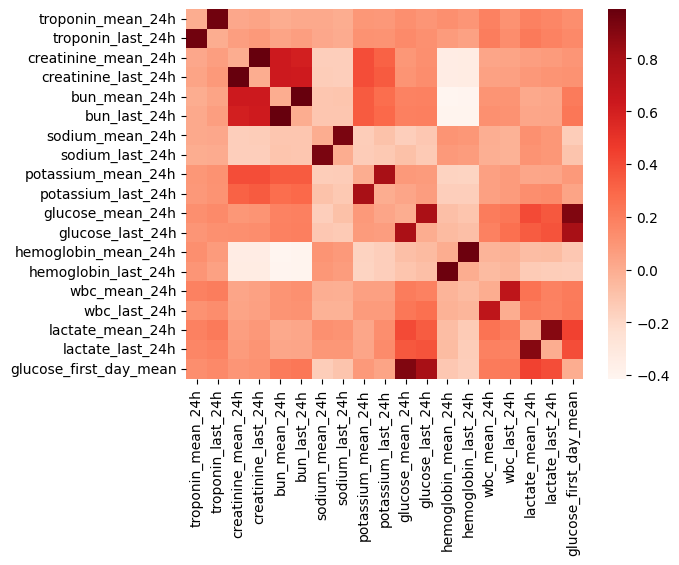

In [ ]:
# locate numerical cols
pci_dtype_locator = df_pci.dtypes.map(lambda x: "int" in str(x).lower() or "float" in str(x).lower())

# extract lab measurement cols
labs_col = ['troponin', 'creatinine', 'bun', 'sodium', 'potassium', 'glucose', 'hemoglobin', 'wbc', 'lactate']

# e.g. match "<lab col>_mean_24h", "<lab col>_last_24h", "<lab col>_first_24h"
col_locator = df_pci.columns.map(lambda x: any([lab_col in str(x).lower() for lab_col in labs_col]))

# obtain correlation matrix and plot
labs_first_last_mean_corr = df_pci.loc[:,pci_dtype_locator & col_locator].corr()

# set diagonal elements to 0 instead of 1
# Convert the DataFrame to a NumPy array for efficient diagonal manipulation
arr = labs_first_last_mean_corr.to_numpy()

# Fill the diagonal of the NumPy array with zeros
np.fill_diagonal(arr, 0)

# Convert the modified NumPy array back to a DataFrame
labs_first_last_mean_corr_modified = pd.DataFrame(arr, index=labs_first_last_mean_corr.index, columns=labs_first_last_mean_corr.columns)


import seaborn as sns
sns.heatmap(labs_first_last_mean_corr_modified, cmap="Reds")

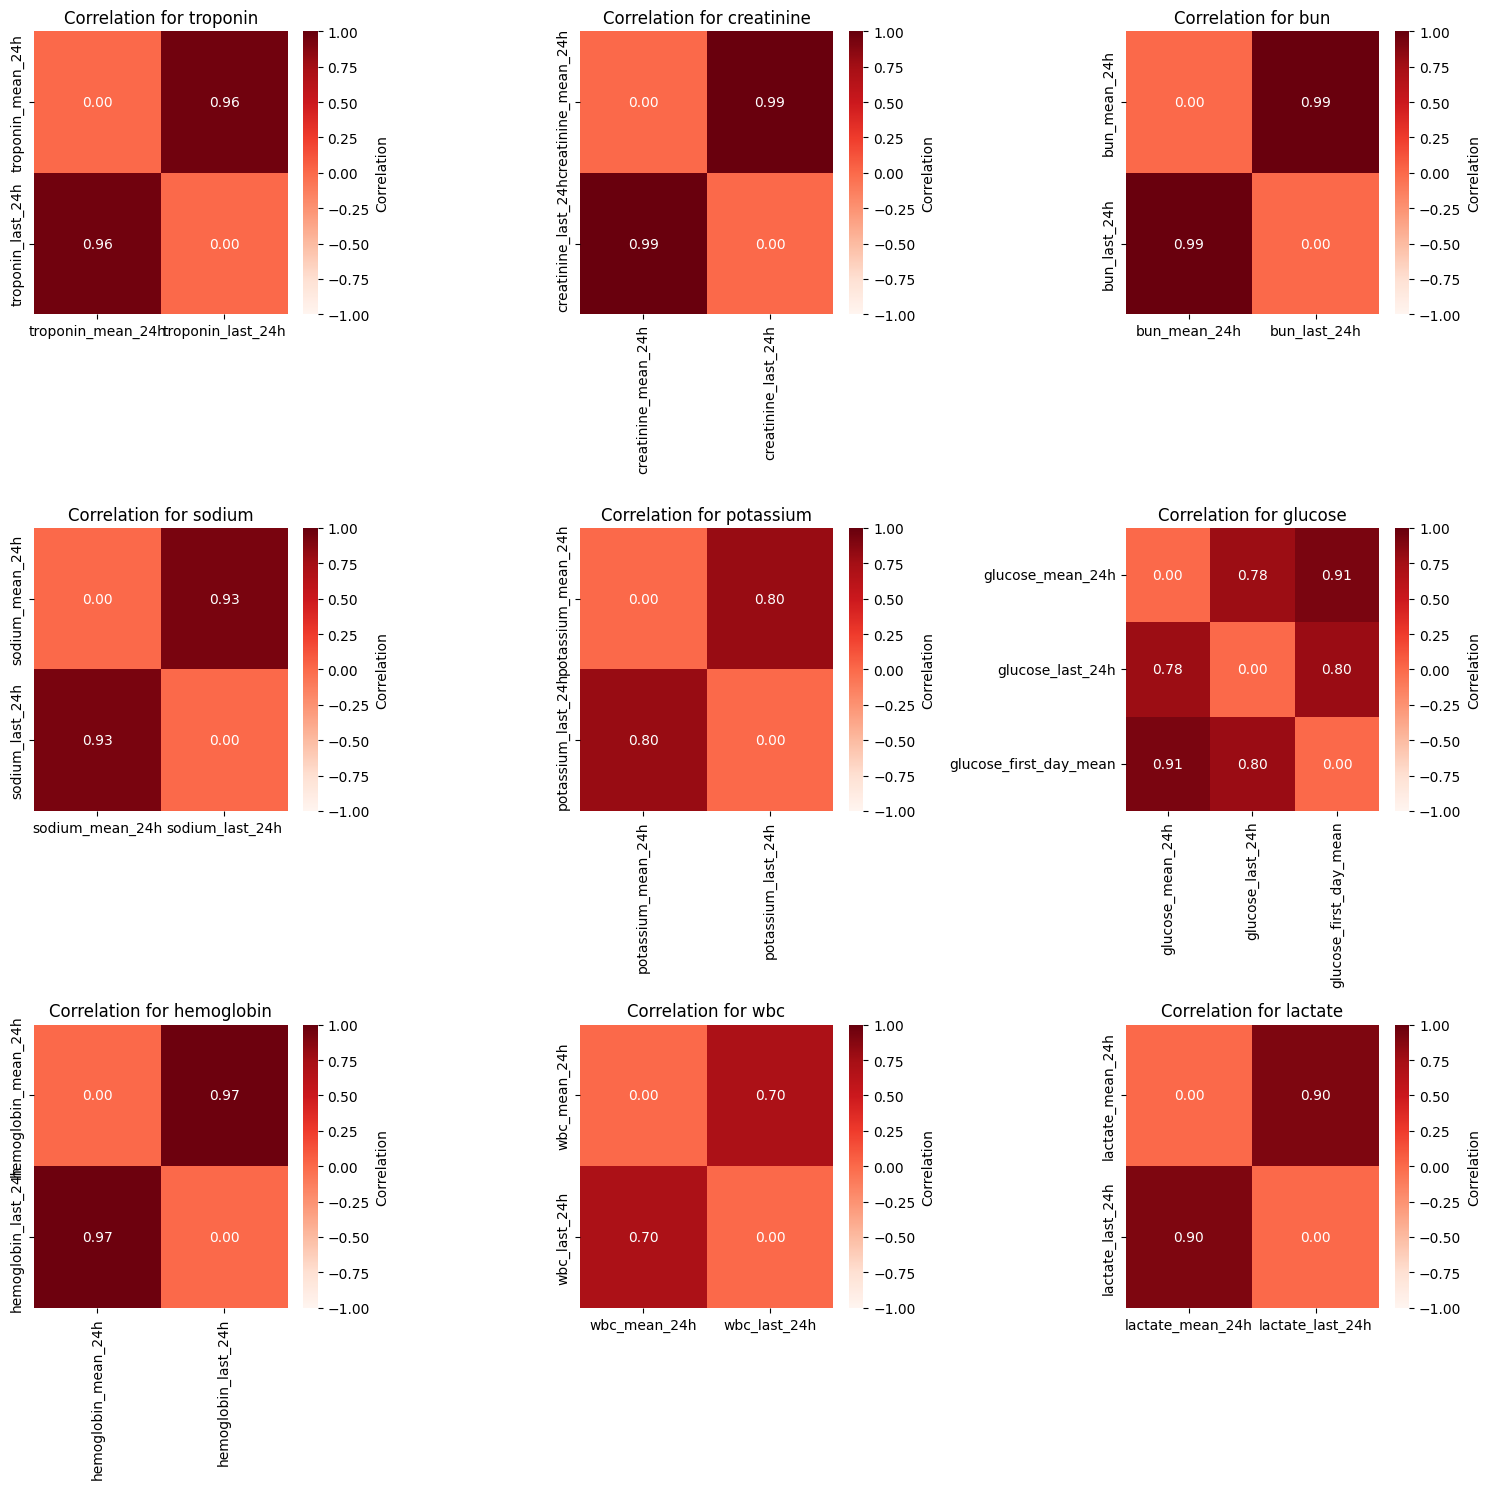

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming labs_first_last_mean_corr_modified is the DataFrame from your previous code
# labs_col is already defined
labs_col = ['troponin', 'creatinine', 'bun', 'sodium', 'potassium', 'glucose', 'hemoglobin', 'wbc', 'lactate']

# Set up a 3x3 subplot grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()  # Flatten the 2D array of axes for easier iteration

# Iterate over each lab and create a heatmap
for idx, lab in enumerate(labs_col):
    # Filter columns containing the lab name (case-insensitive)
    lab_columns = [col for col in labs_first_last_mean_corr_modified.columns if lab.lower() in col.lower()]

    # If no columns match, skip or create an empty plot
    if not lab_columns:
        axes[idx].set_title(f'No data for {lab}')
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])
        continue

    # Extract the submatrix for the current lab
    submatrix = labs_first_last_mean_corr_modified.loc[lab_columns, lab_columns]

    # Plot heatmap
    sns.heatmap(submatrix, cmap="Reds", ax=axes[idx], annot=True, fmt='.2f',
                cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)

    # Set title and labels
    axes[idx].set_title(f'Correlation for {lab}')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Kai's Query for CABG/CBS

## Query string

In [ ]:
query_cbs = """
-- ===========================
-- Config (optional constants)
-- ===========================
DECLARE lower_gap_hours INT64 DEFAULT 24;         -- exclude <24h to avoid unit transfers/leakage
DECLARE upper_gap_days  INT64 DEFAULT 30;         -- 30-day readmission window

-- =========================================================
-- 1) Identify CABG hospital admissions from procedure codes
--    NOTE: ICD-9 may be stored without dots (e.g., 36.15 -> 3615)
-- =========================================================
WITH cabg_procs AS (
  SELECT DISTINCT
    subject_id,
    hadm_id,
    icd_version,
    icd_code
  FROM `physionet-data.mimiciv_3_1_hosp.procedures_icd`
  WHERE
    (
      icd_version = 9
      AND (
        REGEXP_CONTAINS(icd_code, r'^361[0-9]$')  -- 36.10–36.19
        OR REGEXP_CONTAINS(icd_code, r'^362$')    -- 36.2
      )
    )
    OR
    (
      icd_version = 10
      AND REGEXP_CONTAINS(icd_code, r'^021[0-3]') -- 0210xxx–0213xxx
    )
),
cabg_admissions AS (
  SELECT DISTINCT subject_id, hadm_id
  FROM cabg_procs
),

-- =============================================
-- 2) ICU stays for those CABG admissions
-- =============================================
cabg_icustays AS (
  SELECT i.subject_id, i.hadm_id, i.stay_id, i.intime, i.outtime
  FROM `physionet-data.mimiciv_3_1_icu.icustays` AS i
  JOIN cabg_admissions AS c
    USING (subject_id, hadm_id)
),

-- ==========================================================
-- 3) Label 30-day ICU readmission per subject (leakage-aware)
--    y = 1  if 24h <= next_intime - outtime <= 30 days
-- ==========================================================
ordered AS (
  SELECT
    subject_id, hadm_id, stay_id, intime, outtime,
    LEAD(intime) OVER (PARTITION BY subject_id ORDER BY intime) AS next_intime
  FROM cabg_icustays
),
labeled AS (
  SELECT
    subject_id, hadm_id, stay_id, intime, outtime,
    CASE
      WHEN next_intime IS NOT NULL
        AND next_intime > outtime
        AND DATETIME_DIFF(next_intime, outtime, HOUR) >= lower_gap_hours
        AND DATETIME_DIFF(next_intime, outtime, DAY)  <= upper_gap_days
      THEN 1 ELSE 0
    END AS y
  FROM ordered
),

-- =============================================
-- 4) Demographics (patients/admissions)
-- =============================================
demo AS (
  SELECT
    l.subject_id, l.hadm_id, l.stay_id, l.intime, l.outtime, l.y,
    p.gender,
    p.anchor_age         AS age,
    p.anchor_year_group  AS year_group,
    a.admission_type,
    a.insurance,
    a.language,
    a.marital_status,
    a.race,
    a.discharge_location
  FROM labeled AS l
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.patients`   AS p USING (subject_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` AS a USING (subject_id, hadm_id)
),

-- =============================================
-- 5) Comorbidities (Charlson, by hadm_id)
-- =============================================
demo_comorb AS (
  SELECT
    d.*,
    c.charlson_comorbidity_index AS charlson_comorbidity_index,
    c.age_score,
    c.myocardial_infarct,
    c.congestive_heart_failure,
    c.peripheral_vascular_disease,
    c.cerebrovascular_disease,
    c.dementia,
    c.chronic_pulmonary_disease,
    c.rheumatic_disease,
    c.peptic_ulcer_disease,
    c.mild_liver_disease,
    c.diabetes_without_cc,
    c.diabetes_with_cc,
    c.paraplegia,
    c.renal_disease,
    c.malignant_cancer,
    c.severe_liver_disease,
    c.metastatic_solid_tumor,
    c.aids
  FROM demo AS d
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.charlson` AS c
    USING (subject_id, hadm_id)
),

-- =============================================
-- 6) Severity scores (first 24h by stay_id)
-- =============================================
demo_comorb_severity AS (
  SELECT
    dc.*,
    fs.sofa    AS first_day_sofa,
    ap.apsiii  AS apsiii_score,
    ld.lods    AS lods_score,
    os.oasis   AS oasis_score                -- NEW
  FROM demo_comorb AS dc
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.first_day_sofa` AS fs USING (subject_id, hadm_id, stay_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.apsiii`         AS ap USING (subject_id, hadm_id, stay_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.lods`           AS ld USING (subject_id, hadm_id, stay_id)
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.oasis`          AS os USING (subject_id, hadm_id, stay_id) -- NEW
),


-- =============================================
-- labs
-- =============================================
-- Get last lab measurement within 24h of ICU admission
labs_last24h AS (
  WITH windowed AS (
    SELECT
      c.stay_id, c.hadm_id, c.intime,
      l.charttime, l.valuenum,
      UPPER(di.label) AS label,
      l.valueuom
    FROM cabg_icustays c
    JOIN `physionet-data.mimiciv_3_1_hosp.labevents` l
      ON l.hadm_id = c.hadm_id
    JOIN `physionet-data.mimiciv_3_1_hosp.d_labitems` di
      ON di.itemid = l.itemid
    WHERE l.valuenum IS NOT NULL
      AND l.charttime BETWEEN c.intime AND DATETIME_ADD(c.intime, INTERVAL 24 HOUR)
  ),
  mapped AS (
    SELECT
      stay_id,
      charttime,
      valuenum,
      CASE
        WHEN label IN ('TROPONIN T','TROPONIN I','TROPONIN') THEN 'troponin'
        WHEN label IN ('CREATININE')                          THEN 'creatinine'
        WHEN label IN ('UREA NITROGEN','BLOOD UREA NITROGEN','UREA NITROGEN (BUN)','BUN') THEN 'bun'
        WHEN label IN ('SODIUM')                              THEN 'sodium'
        WHEN label IN ('POTASSIUM')                           THEN 'potassium'
        WHEN label IN ('GLUCOSE','GLUCOSE, SERUM','GLUCOSE (POC)') THEN 'glucose'
        WHEN label IN ('HEMOGLOBIN')                          THEN 'hemoglobin'
        WHEN label IN ('WBC','WHITE BLOOD CELLS','WHITE BLOOD CELL COUNT') THEN 'wbc'
        WHEN label IN ('LACTATE','LACTATE (ARTERIAL)')        THEN 'lactate'
        ELSE NULL
      END AS analyte
    FROM windowed
  )
  SELECT
    stay_id,
    ARRAY_AGG(IF(analyte='troponin',   valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS troponin_last_24h,
    ARRAY_AGG(IF(analyte='creatinine', valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS creatinine_last_24h,
    ARRAY_AGG(IF(analyte='bun',        valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS bun_last_24h,
    ARRAY_AGG(IF(analyte='sodium',     valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS sodium_last_24h,
    ARRAY_AGG(IF(analyte='potassium',  valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS potassium_last_24h,
    ARRAY_AGG(IF(analyte='glucose',    valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS glucose_last_24h,
    ARRAY_AGG(IF(analyte='hemoglobin', valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS hemoglobin_last_24h,
    ARRAY_AGG(IF(analyte='wbc',        valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS wbc_last_24h,
    ARRAY_AGG(IF(analyte='lactate',    valuenum, NULL) IGNORE NULLS ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS lactate_last_24h
  FROM mapped
  WHERE analyte IS NOT NULL
  GROUP BY stay_id
),

-- ======
-- utils
-- =====
-- 7b) Utilization (prior ICU count + previous inter-ICU gap in days)
utilization AS (
  SELECT
    d.subject_id, d.hadm_id, d.stay_id, d.intime,
    COUNTIF(i.intime < d.intime) AS n_prior_icu_stays,
    SAFE_DIVIDE(
      DATETIME_DIFF(
        d.intime,
        MAX(IF(i.intime < d.intime, i.outtime, NULL)),  -- latest prior ICU discharge
        HOUR
      ),
      24.0
    ) AS prev_gap_days
  FROM demo AS d
  LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` AS i
    ON i.subject_id = d.subject_id
  GROUP BY d.subject_id, d.hadm_id, d.stay_id, d.intime
),

-- =============================================
-- 7) First-day vitals (means, by stay_id) AND join with lab and utils measurements
-- =============================================
demo_comorb_severity_vitals AS (
  SELECT
    dcs.*,
    v.heart_rate_mean,
    v.sbp_mean,
    v.dbp_mean,
    v.mbp_mean,
    v.resp_rate_mean,
    v.temperature_mean,
    v.spo2_mean,
    v.glucose_mean,

    -- NEW: last-24h labs
    lb.creatinine_last_24h,
    lb.bun_last_24h,
    lb.sodium_last_24h,
    lb.potassium_last_24h,
    lb.glucose_last_24h,
    lb.hemoglobin_last_24h,
    lb.wbc_last_24h,
    lb.lactate_last_24h,
    lb.troponin_last_24h,

    -- NEW: utilization
    u.n_prior_icu_stays,
    u.prev_gap_days
  FROM demo_comorb_severity AS dcs
  LEFT JOIN `physionet-data.mimiciv_3_1_derived.first_day_vitalsign` AS v
    USING (subject_id, stay_id)
  LEFT JOIN labs_last24h AS lb
    USING (stay_id)
  LEFT JOIN utilization AS u
    USING (subject_id, hadm_id, stay_id)
)



-- =============================================
-- 8) Materialize final table
--    (drop intime/outtime if not used as features)
-- =============================================
#CREATE OR REPLACE TABLE `avian-osprey-469804-j0.ml4health.icustays_cabg_features` AS
SELECT *
FROM demo_comorb_severity_vitals
ORDER BY subject_id, intime;

"""

## Query the data

In [ ]:
df_cbs = read_query(query_cbs)

Downloading: 100%|██████████|


# Align my columns to PCI columns
- Only take means for every vital measurements
- Exclude these from evaluations `['is_acute_mi_icd', 'is_acute_mi_trop_refined', 'keep_in_primary_analysis',
                 'is_acute_mi', 'is_chronic_ihd', 'is_complications_post_mi', 'is_other_acute_ihd']` leave for group-based evaluation (perhaps when concatenating, set these to be 0 for non-MI subcohorts?)
            
- Label each subcohort (e.g. `is_mi`, `is_pcr` i.e. is Percutaneous coronary revascularization, `is_cbs` i.e. is coronary bypass surgery)
- Drop `age_score` in `df_cbs`, label age as just `age`
- Label all target to `y`
- Label CCI to `cci` for all (not `charlson` etc)
- Just noticed that CBS sub-cohort hasn't included `['has_cancer', 'has_ckd', 'has_copd', 'has_dm', 'has_hf', 'has_htn']`. Maybe exclude these from analysis?

In [ ]:
sorted(df_cbs.columns)

['admission_type',
 'age',
 'age_score',
 'aids',
 'apsiii_score',
 'bun_last_24h',
 'cerebrovascular_disease',
 'charlson_comorbidity_index',
 'chronic_pulmonary_disease',
 'congestive_heart_failure',
 'creatinine_last_24h',
 'dbp_mean',
 'dementia',
 'diabetes_with_cc',
 'diabetes_without_cc',
 'discharge_location',
 'first_day_sofa',
 'gender',
 'glucose_last_24h',
 'glucose_mean',
 'hadm_id',
 'heart_rate_mean',
 'hemoglobin_last_24h',
 'insurance',
 'intime',
 'lactate_last_24h',
 'language',
 'lods_score',
 'malignant_cancer',
 'marital_status',
 'mbp_mean',
 'metastatic_solid_tumor',
 'mild_liver_disease',
 'myocardial_infarct',
 'n_prior_icu_stays',
 'oasis_score',
 'outtime',
 'paraplegia',
 'peptic_ulcer_disease',
 'peripheral_vascular_disease',
 'potassium_last_24h',
 'prev_gap_days',
 'race',
 'renal_disease',
 'resp_rate_mean',
 'rheumatic_disease',
 'sbp_mean',
 'severe_liver_disease',
 'sodium_last_24h',
 'spo2_mean',
 'stay_id',
 'subject_id',
 'temperature_mean',
 'tro

In [ ]:
sorted(df_pci.columns)

['admission_type',
 'age_est',
 'aids',
 'apsiii_prob',
 'apsiii_score',
 'bun_last_24h',
 'bun_mean_24h',
 'cci',
 'cerebrovascular_disease',
 'chronic_pulmonary_disease',
 'congestive_heart_failure',
 'creatinine_last_24h',
 'creatinine_mean_24h',
 'dbp_first_day_max',
 'dbp_first_day_mean',
 'dbp_first_day_min',
 'dementia',
 'diabetes_with_cc',
 'diabetes_without_cc',
 'gender',
 'glucose_first_day_mean',
 'glucose_last_24h',
 'glucose_mean_24h',
 'hadm_id',
 'has_cancer',
 'has_ckd',
 'has_copd',
 'has_dm',
 'has_hf',
 'has_htn',
 'hemoglobin_last_24h',
 'hemoglobin_mean_24h',
 'hr_first_day_max',
 'hr_first_day_mean',
 'hr_first_day_min',
 'insurance',
 'intime',
 'lactate_last_24h',
 'lactate_mean_24h',
 'language',
 'malignant_cancer',
 'map_first_day_mean',
 'marital_status',
 'metastatic_solid_tumor',
 'mild_liver_disease',
 'myocardial_infarct',
 'n_prior_icu_stays',
 'oasis',
 'outtime',
 'paraplegia',
 'peptic_ulcer_disease',
 'peripheral_vascular_disease',
 'potassium_las

In [ ]:
sorted(df.columns)

['admission_type',
 'age_at_icu',
 'aids',
 'apsiii_prob',
 'apsiii_score',
 'bun_last_24h',
 'cerebrovascular_disease',
 'charlson',
 'chronic_pulmonary_disease',
 'congestive_heart_failure',
 'creatinine_last_24h',
 'dbp_max',
 'dbp_mean',
 'dbp_min',
 'dementia',
 'diabetes_with_cc',
 'diabetes_without_cc',
 'gender',
 'glucose_last_24h',
 'glucose_max',
 'glucose_mean',
 'glucose_min',
 'hadm_id',
 'has_cancer',
 'has_ckd',
 'has_copd',
 'has_dm',
 'has_hf',
 'has_htn',
 'heart_rate_max',
 'heart_rate_mean',
 'heart_rate_min',
 'hemoglobin_last_24h',
 'insurance',
 'intime',
 'is_acute_mi',
 'is_acute_mi_icd',
 'is_acute_mi_trop_refined',
 'is_chronic_ihd',
 'is_complications_post_mi',
 'is_other_acute_ihd',
 'keep_in_primary_analysis',
 'lactate_last_24h',
 'language',
 'malignant_cancer',
 'marital_status',
 'mbp_max',
 'mbp_mean',
 'mbp_min',
 'metastatic_solid_tumor',
 'mild_liver_disease',
 'myocardial_infarct',
 'n_prior_icu_stays',
 'next_intime',
 'oasis_score',
 'outtime',

# For the hard part: merge into one unified CHD cohort.

## Define our "expected schema" and a "harmonizer" function to the expected schema

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1) Canonical column list
# =========================
CANONICAL_COLS = [
    # IDs
    "subject_id","hadm_id","stay_id",
    # Target
    "y",
    # Subcohort flags
    "is_mi","is_pcr","is_cbs",
    # Demographics
    "age","gender","race","admission_type","insurance","language","marital_status",
    # Comorbidity index + components
    "cci",
    "myocardial_infarct","congestive_heart_failure","peripheral_vascular_disease","cerebrovascular_disease",
    "dementia","chronic_pulmonary_disease","rheumatic_disease","peptic_ulcer_disease","mild_liver_disease",
    "diabetes_without_cc","diabetes_with_cc","paraplegia","renal_disease","malignant_cancer",
    "severe_liver_disease","metastatic_solid_tumor","aids",
    # Severity
    "first_day_sofa","apsiii_score","oasis_score","lods_score",
    # Vitals (means only)
    "heart_rate_mean","sbp_mean","dbp_mean","mbp_mean","resp_rate_mean","temperature_mean","spo2_mean","glucose_mean",
    # Labs (last value in first 24h)
    "creatinine_last_24h","bun_last_24h","sodium_last_24h","potassium_last_24h","glucose_last_24h",
    "hemoglobin_last_24h","wbc_last_24h","lactate_last_24h","troponin_last_24h",
    # Utilization
    "n_prior_icu_stays","prev_gap_days",
    # MI phenotype flags (kept only in FULL export; zeroed for non-MI)
    "is_acute_mi_icd","is_acute_mi_trop_refined","is_acute_mi","is_chronic_ihd","is_complications_post_mi","is_other_acute_ihd",
]

# dtypes
INT_FLAGS = [
    "y","is_mi","is_pcr","is_cbs",
    "myocardial_infarct","congestive_heart_failure","peripheral_vascular_disease","cerebrovascular_disease",
    "dementia","chronic_pulmonary_disease","rheumatic_disease","peptic_ulcer_disease","mild_liver_disease",
    "diabetes_without_cc","diabetes_with_cc","paraplegia","renal_disease","malignant_cancer",
    "severe_liver_disease","metastatic_solid_tumor","aids",
    "is_acute_mi_icd","is_acute_mi_trop_refined","is_acute_mi","is_chronic_ihd","is_complications_post_mi","is_other_acute_ihd",
]
FLOAT_COLS = [
    "age","cci","first_day_sofa","apsiii_score","oasis_score","lods_score",
    "heart_rate_mean","sbp_mean","dbp_mean","mbp_mean","resp_rate_mean","temperature_mean","spo2_mean","glucose_mean",
    "creatinine_last_24h","bun_last_24h","sodium_last_24h","potassium_last_24h","glucose_last_24h",
    "hemoglobin_last_24h","wbc_last_24h","lactate_last_24h","troponin_last_24h",
    "n_prior_icu_stays","prev_gap_days"
]

# ==================================
# 2) Per-cohort rename dictionaries
# ==================================
RENAME_MI = {
    "y_readmit_30d": "y",
    "age_at_icu": "age",
    "charlson": "cci",
    "charlson_comorbidity_index": "cci",
    "sofa_firstday_total": "first_day_sofa",
}




RENAME_PCI = {
    "charlson_comorbidity_index": "cci",
    # update (29/10) rename vital cols to avoid 100% NAs!!
    "hr_first_day_mean":"heart_rate_mean",
    "sbp_first_day_mean":"sbp_mean",
    "dbp_first_day_mean":"dbp_mean",
    "map_first_day_mean":"mbp_mean",
    "rr_first_day_mean":"resp_rate_mean",
    "temp_first_day_mean":"temperature_mean",
    "spo2_first_day_mean":"spo2_mean",
    "glucose_first_day_mean":"glucose_mean",
    "sofa_first_day":"first_day_sofa",
    "oasis":"oasis_score",
    "age_est":"age"
    # target is already y
}


RENAME_CBS = {
    "charlson_comorbidity_index":"cci",
    "sofa": "first_day_sofa",
    "apsiii": "apsiii_score",
    "oasis": "oasis_score",
    "lods": "lods_score",
    # demographics already aliased in the cabg SQL to age/gender/race/admission_type/insurance/language/marital_status
}

# ===================================================
# 3) Harmonizer: drop mins/maxs, set flags, align cols
# ===================================================
def harmonize(df: pd.DataFrame, cohort: str, keep_mi_flags_in_full=True) -> pd.DataFrame:
    df = df.copy()

    # a) rename
    if cohort == "mi":
        df = df.rename(columns=RENAME_MI)
        df["is_mi"], df["is_pcr"], df["is_cbs"] = 1, 0, 0
        # ensure MI phenotype flags exist (fill 0 if missing)
        for col in ["is_acute_mi_icd","is_acute_mi_trop_refined","is_acute_mi","is_chronic_ihd","is_complications_post_mi","is_other_acute_ihd"]:
            if col not in df.columns: df[col] = 0
    elif cohort == "pci":
        df = df.rename(columns=RENAME_PCI)
        df["is_mi"], df["is_pcr"], df["is_cbs"] = 0, 1, 0
        # set MI flags to 0
        for col in ["is_acute_mi_icd","is_acute_mi_trop_refined","is_acute_mi","is_chronic_ihd","is_complications_post_mi","is_other_acute_ihd"]:
            df[col] = 0
    elif cohort == "cbs":
        df = df.rename(columns=RENAME_CBS)
        df["is_mi"], df["is_pcr"], df["is_cbs"] = 0, 0, 1
        # drop age_score if present
        if "age_score" in df.columns:
            df = df.drop(columns=["age_score"])
        # set MI flags to 0
        for col in ["is_acute_mi_icd","is_acute_mi_trop_refined","is_acute_mi","is_chronic_ihd","is_complications_post_mi","is_other_acute_ihd"]:
            df[col] = 0
    else:
        raise ValueError("cohort must be one of: 'mi','pci','cbs'.")

    # b) vitals: keep means only
    drop_suffixes = ("_min","_max")
    df = df[[c for c in df.columns if not c.endswith(drop_suffixes)]]

    # c) ensure required demographics present (discharge_location intentionally omitted -- risk leakage because)
    for col in ["insurance","language","marital_status","admission_type","race","gender","age"]:
        if col not in df.columns: df[col] = None

    # d) unify charlson components presence (fill 0 if absent)
    for col in [
        "myocardial_infarct","congestive_heart_failure","peripheral_vascular_disease","cerebrovascular_disease",
        "dementia","chronic_pulmonary_disease","rheumatic_disease","peptic_ulcer_disease","mild_liver_disease",
        "diabetes_without_cc","diabetes_with_cc","paraplegia","renal_disease","malignant_cancer",
        "severe_liver_disease","metastatic_solid_tumor","aids"
    ]:
        if col not in df.columns: df[col] = 0

    # e) ensure labs/utilization exist (fill NaN)
    for col in [
        "creatinine_last_24h","bun_last_24h","sodium_last_24h","potassium_last_24h","glucose_last_24h",
        "hemoglobin_last_24h","wbc_last_24h","lactate_last_24h","troponin_last_24h",
        "n_prior_icu_stays","prev_gap_days"
    ]:
        if col not in df.columns: df[col] = np.nan

    # f) severity presence
    for col in ["first_day_sofa","apsiii_score","oasis_score","lods_score"]:
        if col not in df.columns: df[col] = np.nan

    # g) target / cci
    if "y" not in df.columns:
        # MI case should have y_readmit_30d mapped already; else default to 0
        df["y"] = df.get("y_readmit_30d", 0)
    if "cci" not in df.columns:
        df["cci"] = df.get("charlson", np.nan)

    # h) add any missing canonical cols with sensible defaults
    for col in CANONICAL_COLS:
        if col not in df.columns:
            if col in INT_FLAGS:
                df[col] = 0
            elif col in FLOAT_COLS:
                df[col] = np.nan
            else:
                df[col] = None

    # i) drop extra columns (e.g., discharge_location, has_* flags)
    df = df[CANONICAL_COLS]

    # j) dtypes
    for col in INT_FLAGS:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("int64")
    for col in FLOAT_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # k) target safety
    df["y"] = df["y"].fillna(0).astype("int64")

    return df




## Now, harmonize each sub-cohort (MI, PCI, CBS), and merge harmonized sub-cohort into one

In [ ]:
# ==================================
# 4) Load → harmonize → concat → save
# ==================================

df_mi = df

df_mi_h  = harmonize(df_mi,  "mi")
df_pci_h = harmonize(df_pci, "pci")
df_cbs_h = harmonize(df_cbs, "cbs")

# Full dataset (keep MI phenotype flags for subgroup eval)
merged_full = pd.concat([df_mi_h, df_pci_h, df_cbs_h], ignore_index=True)
#merged_full.to_csv("merged_chd_full.csv", index=False)

# Modeling dataset (drop MI phenotype flags)
drop_mi_flags = ["is_acute_mi_icd","is_acute_mi_trop_refined","is_acute_mi","is_chronic_ihd","is_complications_post_mi","is_other_acute_ihd"]
merged_model = merged_full.drop(columns=drop_mi_flags)
#merged_model.to_csv("merged_chd_model.csv", index=False)

# Quick sanity
print(merged_full.shape, merged_model.shape)
print(merged_model.dtypes.loc[["y","is_mi","is_pcr","is_cbs","n_prior_icu_stays"]])

(15445, 61) (15445, 55)
y                    int64
is_mi                int64
is_pcr               int64
is_cbs               int64
n_prior_icu_stays    Int64
dtype: object


/tmp/ipython-input-3579325125.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_full = pd.concat([df_mi_h, df_pci_h, df_cbs_h], ignore_index=True)


In [ ]:
merged_full

,subject_id,hadm_id,stay_id,y,is_mi,is_pcr,is_cbs,age,gender,race,...,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,prev_gap_days,is_acute_mi_icd,is_acute_mi_trop_refined,is_acute_mi,is_chronic_ihd,is_complications_post_mi,is_other_acute_ihd
0,10154719,21914168,35702330,0,1,0,0,68,M,WHITE,...,NaN,1.03,1,1014.000000,1,1,1,0,0,0
1,10949596,26086151,31406916,0,1,0,0,79,M,WHITE,...,NaN,NaN,0,NaN,0,0,0,1,0,0
2,11038900,29967401,30447128,1,1,0,0,76,M,UNKNOWN,...,1.4,0.37,0,NaN,1,1,1,0,0,0
3,11038900,29967401,33744055,0,1,0,0,76,M,UNKNOWN,...,NaN,2.83,1,1.666667,1,1,1,0,0,0
4,11384756,21111442,31242950,0,1,0,0,61,F,WHITE,...,0.8,NaN,0,NaN,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15440,19995091,27602139,32457489,0,0,0,1,65,M,WHITE,...,1.6,NaN,0,NaN,0,0,0,0,0,0
15441,19995780,21942461,36805359,0,0,0,1,84,M,WHITE,...,1.6,NaN,0,NaN,0,0,0,0,0,0
15442,19995790,22970553,34995866,0,0,0,1,66,M,WHITE,...,2.3,NaN,0,NaN,0,0,0,0,0,0
15443,19996673,29017569,38026904,0,0,0,1,72,F,WHITE,...,NaN,2.27,0,NaN,0,0,0,0,0,0


In [ ]:
merged_model

,subject_id,hadm_id,stay_id,y,is_mi,is_pcr,is_cbs,age,gender,race,...,bun_last_24h,sodium_last_24h,potassium_last_24h,glucose_last_24h,hemoglobin_last_24h,wbc_last_24h,lactate_last_24h,troponin_last_24h,n_prior_icu_stays,prev_gap_days
0,10154719,21914168,35702330,0,1,0,0,68,M,WHITE,...,12.0,141.0,3.2,136.0,13.4,12.4,NaN,1.03,1,1014.000000
1,10949596,26086151,31406916,0,1,0,0,79,M,WHITE,...,14.0,128.0,3.6,99.0,11.2,12.2,NaN,NaN,0,NaN
2,11038900,29967401,30447128,1,1,0,0,76,M,UNKNOWN,...,22.0,135.0,3.9,215.0,7.7,11.1,1.4,0.37,0,NaN
3,11038900,29967401,33744055,0,1,0,0,76,M,UNKNOWN,...,16.0,133.0,4.1,189.0,8.2,11.6,NaN,2.83,1,1.666667
4,11384756,21111442,31242950,0,1,0,0,61,F,WHITE,...,17.0,134.0,4.1,119.0,10.7,10.4,0.8,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15440,19995091,27602139,32457489,0,0,0,1,65,M,WHITE,...,13.0,135.0,4.4,95.0,13.3,12.8,1.6,NaN,0,NaN
15441,19995780,21942461,36805359,0,0,0,1,84,M,WHITE,...,11.0,134.0,5.0,145.0,11.2,14.9,1.6,NaN,0,NaN
15442,19995790,22970553,34995866,0,0,0,1,66,M,WHITE,...,18.0,133.0,4.4,126.0,10.9,10.9,2.3,NaN,0,NaN
15443,19996673,29017569,38026904,0,0,0,1,72,F,WHITE,...,38.0,135.0,5.4,109.0,8.4,9.8,NaN,2.27,0,NaN


In [ ]:
merged_model[merged_model.is_pcr == True].describe().T.sort_values(by='count')

,count,mean,std,min,25%,50%,75%,max
lods_score,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
prev_gap_days,274.0,158.803528,451.805137,0.0,0.552083,3.145833,12.041667,3325.833333
lactate_last_24h,941.0,2.240808,2.555456,0.4,1.2,1.5,2.1,20.7
troponin_last_24h,1782.0,3.120449,4.090594,0.01,0.53,1.68,4.0775,51.84
temperature_mean,2281.0,36.721499,0.481314,32.2,36.538,36.73,36.926667,38.536
wbc_last_24h,2305.0,11.304946,7.094652,0.0,7.8,10.1,13.2,131.0
glucose_mean,2305.0,157.09908,61.670959,51.0,116.5,138.333333,179.285714,579.0
hemoglobin_last_24h,2308.0,11.32253,2.224912,3.9,9.6,11.3,13.0,18.5
glucose_last_24h,2319.0,147.964209,69.761408,15.0,108.0,127.0,163.0,1000.0
bun_last_24h,2322.0,26.782084,19.91535,3.0,14.0,20.0,32.0,183.0


In [ ]:
merged_model.shape[0] == df_mi.shape[0] + df_cbs.shape[0] + df_pci.shape[0]

True

In [ ]:
merged_model.dtypes.map(lambda x: str(x).lower()).sort_values()

,0
prev_gap_days,float64
heart_rate_mean,float64
sbp_mean,float64
dbp_mean,float64
mbp_mean,float64
temperature_mean,float64
spo2_mean,float64
glucose_mean,float64
creatinine_last_24h,float64
resp_rate_mean,float64


## Save the datasets (full and for modelling)

In [ ]:
merged_model.drop(columns=['lods_score']).to_csv("merged_chd_model_v2.csv", index=False)

In [ ]:
merged_full.drop(columns=['lods_score']).to_csv("merged_chd_full_v2.csv", index=False)